# Part 3: Closing the Loop (Optimization) 🔋
**Supported by the WEL Research Institute (WEL-T) - EDITS Project**

The ultimate goal of a Digital Twin is to **make decisions**. 

Imagine our Virtual Power Plant connects to a fluctuating energy market. We want to use a massive community battery to save money: **Charge** when energy is cheap (or overproduced), and **Discharge** when it is expensive.

In [76]:
import joblib
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt

In [77]:
# ==========================================
# 1. LOAD MODELS & TEST DATA
# ==========================================
targets_config = {
    "Solar_kW": {"exog": ["temp_air", "ghi"], "clip": True},
    "Wind_kW": {"exog": ["wind_speed", "wind_speed_100m"], "clip": True},
    "Demand_kW": {"exog": ["temp_air"], "clip": True},
    "Price_EUR_per_kWh": {"exog": ["temp_air", "wind_speed", "ghi"], "clip": False}
}

# Load the Random Forest models saved in Notebook 2
models = {tgt: joblib.load(f"rf_{tgt}_model.joblib") for tgt in targets_config.keys()}

# Load the test dataset (our "future" reality)
df_test = pd.read_csv("synthetic_df_test.csv", index_col=0, parse_dates=True)

# Re-engineer calendar features for the test set
df_test["Hour"] = df_test.index.hour
df_test["Hour_Sin"] = np.sin(2 * np.pi * df_test["Hour"] / 24)
df_test["Hour_Cos"] = np.cos(2 * np.pi * df_test["Hour"] / 24)
df_test["DayOfYear"] = df_test.index.dayofyear
df_test["Season_Sin"] = np.sin(2 * np.pi * df_test["DayOfYear"] / 365.25)
df_test["Season_Cos"] = np.cos(2 * np.pi * df_test["DayOfYear"] / 365.25)

base_calendar = ["Hour_Sin", "Hour_Cos", "Season_Sin", "Season_Cos"]

In [78]:
# ==========================================
# 2. RECURSIVE 24-HOUR FORECAST ENGINE
# ==========================================
def generate_24h_forecast(start_idx, horizon=24):
    """
    Autoregressively predicts the next 24 hours.
    It uses perfectly forecasted weather (exogenous vars) but 
    must rely on its own past predictions for target lags.
    """
    # Initialize history with the last 3 *actual* hours before the start point
    history = {
        tgt: df_test[tgt].iloc[start_idx-3 : start_idx].tolist() 
        for tgt in targets_config.keys()
    }
    
    forecasts = {tgt: [] for tgt in targets_config.keys()}
    time_index = df_test.index[start_idx : start_idx + horizon]
    
    for h in range(horizon):
        current_idx = start_idx + h
        current_row = df_test.iloc[current_idx]
        
        for tgt, config in targets_config.items():
            # Build the feature dictionary exactly as the model expects
            features = {c: current_row[c] for c in base_calendar + config["exog"]}
            
            # Extract dynamic lags from our updating history
            features[f"{tgt}_lag1"] = history[tgt][-1]
            features[f"{tgt}_lag2"] = history[tgt][-2]
            features[f"{tgt}_lag3"] = history[tgt][-3]
            
            # Extract dynamic rolling stats
            recent_3 = history[tgt][-3:]
            features[f"{tgt}_roll_mean3"] = np.mean(recent_3)
            features[f"{tgt}_roll_std3"] = np.std(recent_3, ddof=1) if len(recent_3) > 1 else 0.0
            
            # Ensure strict column order for the Random Forest
            ordered_cols = base_calendar + config["exog"] + [
                f"{tgt}_lag1", f"{tgt}_lag2", f"{tgt}_lag3", 
                f"{tgt}_roll_mean3", f"{tgt}_roll_std3"
            ]
            X_pred = pd.DataFrame([features])[ordered_cols]
            
            # Predict step t+h
            pred = models[tgt].predict(X_pred)[0]
            if config["clip"]:
                pred = max(0.0, pred)
                
            forecasts[tgt].append(pred)
            
            # FEEDBACK LOOP: Append the prediction to the history for the next iteration
            history[tgt].append(pred)
            
    return pd.DataFrame(forecasts, index=time_index)


In [79]:
# Pick a starting point (e.g., 24 hours into the test set)
START_IDX = 36  
HORIZON = 24

print("🤖 Generating multi-step ahead AI forecasts...")
df_forecast = generate_24h_forecast(START_IDX, HORIZON)

🤖 Generating multi-step ahead AI forecasts...


In [80]:
# ==========================================
# 3. BATTERY OPTIMIZATION (PuLP) USING AI FORECASTS
# ==========================================
# Battery specs
BATTERY_CAPACITY = 100.0  # kWh
MAX_POWER = 30.0          # kW max charge/discharge rate
INITIAL_SOC = 20.0        # kWh initial state
EFFICIENCY = 0.95         

prob = pulp.LpProblem("Battery_Scheduling_AI", pulp.LpMinimize)
times = range(HORIZON)


In [81]:
# Decision Variables
P_buy = pulp.LpVariable.dicts("Buy_kW", times, lowBound=0)
P_sell = pulp.LpVariable.dicts("Sell_kW", times, lowBound=0)
P_charge = pulp.LpVariable.dicts("Charge_kW", times, lowBound=0, upBound=MAX_POWER)
P_discharge = pulp.LpVariable.dicts("Discharge_kW", times, lowBound=0, upBound=MAX_POWER)
SoC = pulp.LpVariable.dicts("State_Of_Charge_kWh", times, lowBound=0, upBound=BATTERY_CAPACITY)


In [82]:
# Retrieve AI Forecast arrays
pv_f = df_forecast["Solar_kW"].values
wind_f = df_forecast["Wind_kW"].values
demand_f = df_forecast["Demand_kW"].values
price_buy_f = df_forecast["Price_EUR_per_kWh"].values
price_sell_f = price_buy_f * 0.75  


In [83]:
# Objective: Minimize predicted costs
prob += pulp.lpSum([P_buy[t] * price_buy_f[t] - P_sell[t] * price_sell_f[t] for t in times])

In [84]:
# Constraints
for t in times:
    # A. Energy Balance based on FORECASTS
    prob += (pv_f[t] + wind_f[t] + P_buy[t] + P_discharge[t] == 
             demand_f[t] + P_sell[t] + P_charge[t], f"EnergyBalance_{t}")
    
    # B. Battery State of Charge (SoC) Dynamics
    if t == 0:
        prob += (SoC[t] == INITIAL_SOC + (P_charge[t] * EFFICIENCY) - (P_discharge[t] / EFFICIENCY), f"SoC_{t}")
    else:
        prob += (SoC[t] == SoC[t-1] + (P_charge[t] * EFFICIENCY) - (P_discharge[t] / EFFICIENCY), f"SoC_{t}")

print("⚡ Running PuLP Optimizer on AI forecasts...")
status = prob.solve()
print(f"Optimization Status: {pulp.LpStatus[status]}")

⚡ Running PuLP Optimizer on AI forecasts...
Optimization Status: Optimal


In [85]:
# ==========================================
# 4. VISUALIZE: THE DIGITAL TWIN IN ACTION
# ==========================================
df_opt = df_forecast.copy()

# Extract ALL actions from the PuLP variables
df_opt["Action_Charge_kW"] = [P_charge[t].varValue for t in times]
df_opt["Action_Discharge_kW"] = [P_discharge[t].varValue for t in times]
df_opt["Optimal_SoC_kWh"] = [SoC[t].varValue for t in times]

# Extract Grid Actions
df_opt["Action_Buy_kW"] = [P_buy[t].varValue for t in times]
df_opt["Action_Sell_kW"] = [P_sell[t].varValue for t in times]

# Calculate Net Grid interaction (Positive = Buying from grid, Negative = Selling to grid)
df_opt["Net_Grid_kW"] = df_opt["Action_Buy_kW"] - df_opt["Action_Sell_kW"]

# Also grab the *actual* reality to see what the Twin was up against
df_actuals = df_test.iloc[START_IDX : START_IDX + HORIZON]


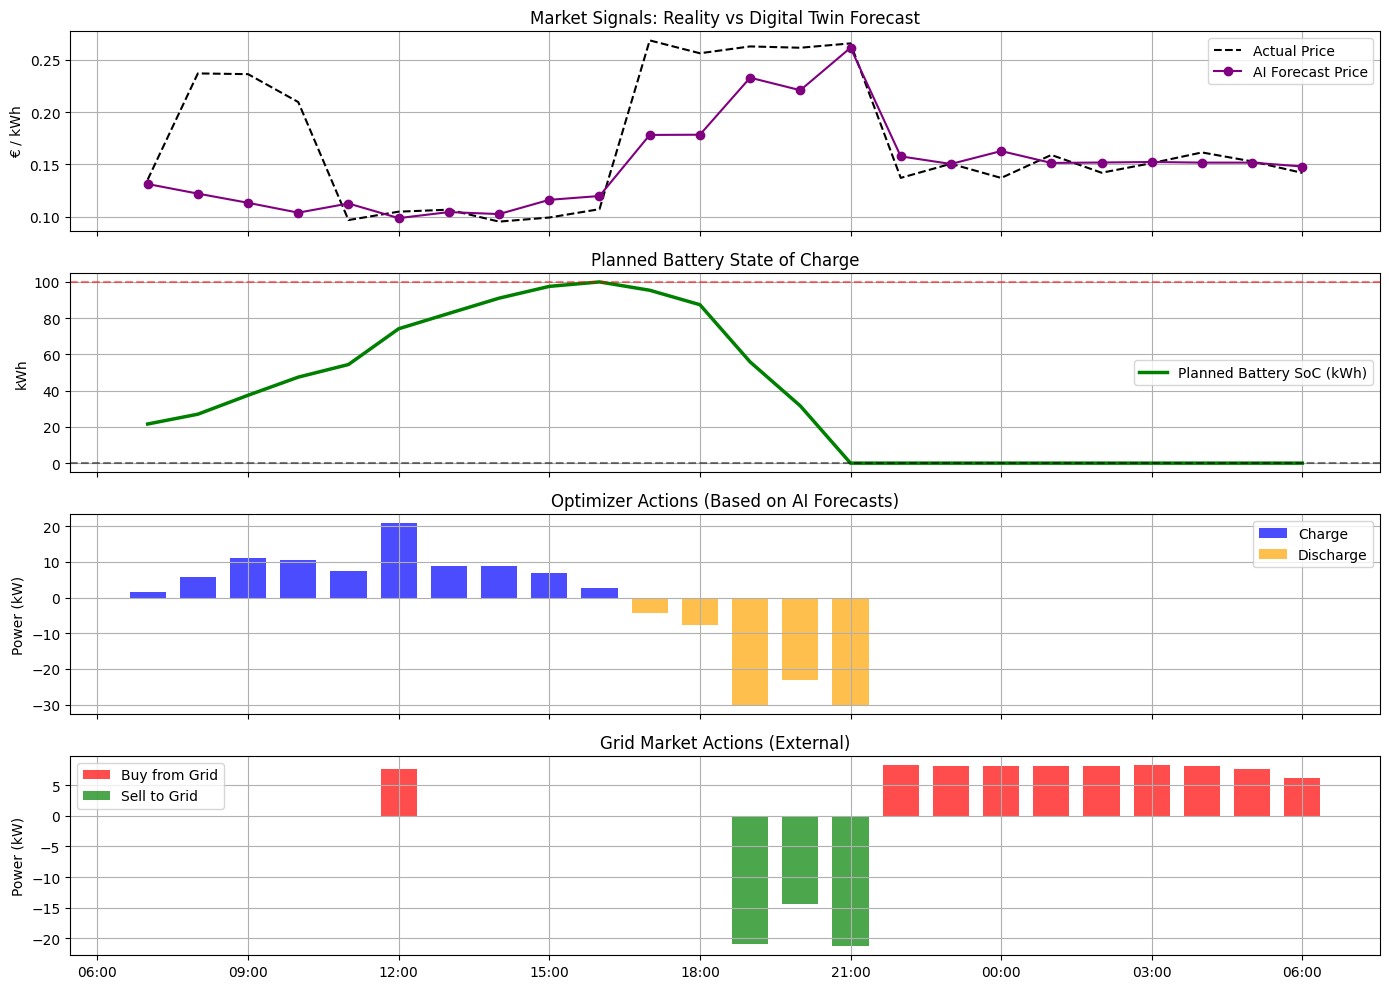

In [86]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(4, 1, figsize=(14, 10), sharex=True)


# Plot 1: AI Price Forecast vs Reality
ax[0].plot(df_actuals.index, df_actuals["Price_EUR_per_kWh"], label="Actual Price", color="black", linestyle="--")
ax[0].plot(df_opt.index, df_opt["Price_EUR_per_kWh"], label="AI Forecast Price", color="purple", marker="o")
ax[0].set_title("Market Signals: Reality vs Digital Twin Forecast")
ax[0].set_ylabel("€ / kWh")
ax[0].legend()
ax[0].grid(True)

# Plot 2: State of Charge Planning
ax[1].plot(df_opt.index, df_opt["Optimal_SoC_kWh"], label="Planned Battery SoC (kWh)", color="green", linewidth=2.5)
ax[1].axhline(BATTERY_CAPACITY, color="red", linestyle="--", alpha=0.5)
ax[1].axhline(0, color="black", linestyle="--", alpha=0.5)
ax[1].set_title("Planned Battery State of Charge")
ax[1].set_ylabel("kWh")
ax[1].legend()
ax[1].grid(True)

# Plot 3: Battery Actions
ax[2].bar(df_opt.index, df_opt["Action_Charge_kW"], label="Charge", color="blue", width=0.03, alpha=0.7)
ax[2].bar(df_opt.index, -df_opt["Action_Discharge_kW"], label="Discharge", color="orange", width=0.03, alpha=0.7)
ax[2].set_title("Optimizer Actions (Based on AI Forecasts)")
ax[2].set_ylabel("Power (kW)")
ax[2].legend()
ax[2].grid(True)


# Plot 4: Grid Interactions (Buy/Sell)
ax[3].bar(df_opt.index, df_opt["Action_Buy_kW"], label="Buy from Grid", color="red", width=0.03, alpha=0.7)
ax[3].bar(df_opt.index, -df_opt["Action_Sell_kW"], label="Sell to Grid", color="green", width=0.03, alpha=0.7)
ax[3].set_title("Grid Market Actions (External)")
ax[3].set_ylabel("Power (kW)")
ax[3].legend(loc="upper left")
ax[3].grid(True)
ax[3].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()

# Part 4: The Oracle (Perfect Foresight) 🔮
What if we had a crystal ball and knew the exact weather, demand, and prices with 100% certainty?
Let's run the exact same optimizer, but feed it `df_actuals` instead of `df_forecast`.

🔮 Running PuLP Optimizer on Perfect Foresight (Oracle)...

💸 Financial Comparison over 24 Hours:
Cost using Perfect Foresight (Oracle): € 11.23
Cost using AI Forecast Strategy:       € 17.92
Loss due to forecast errors:           € 6.69


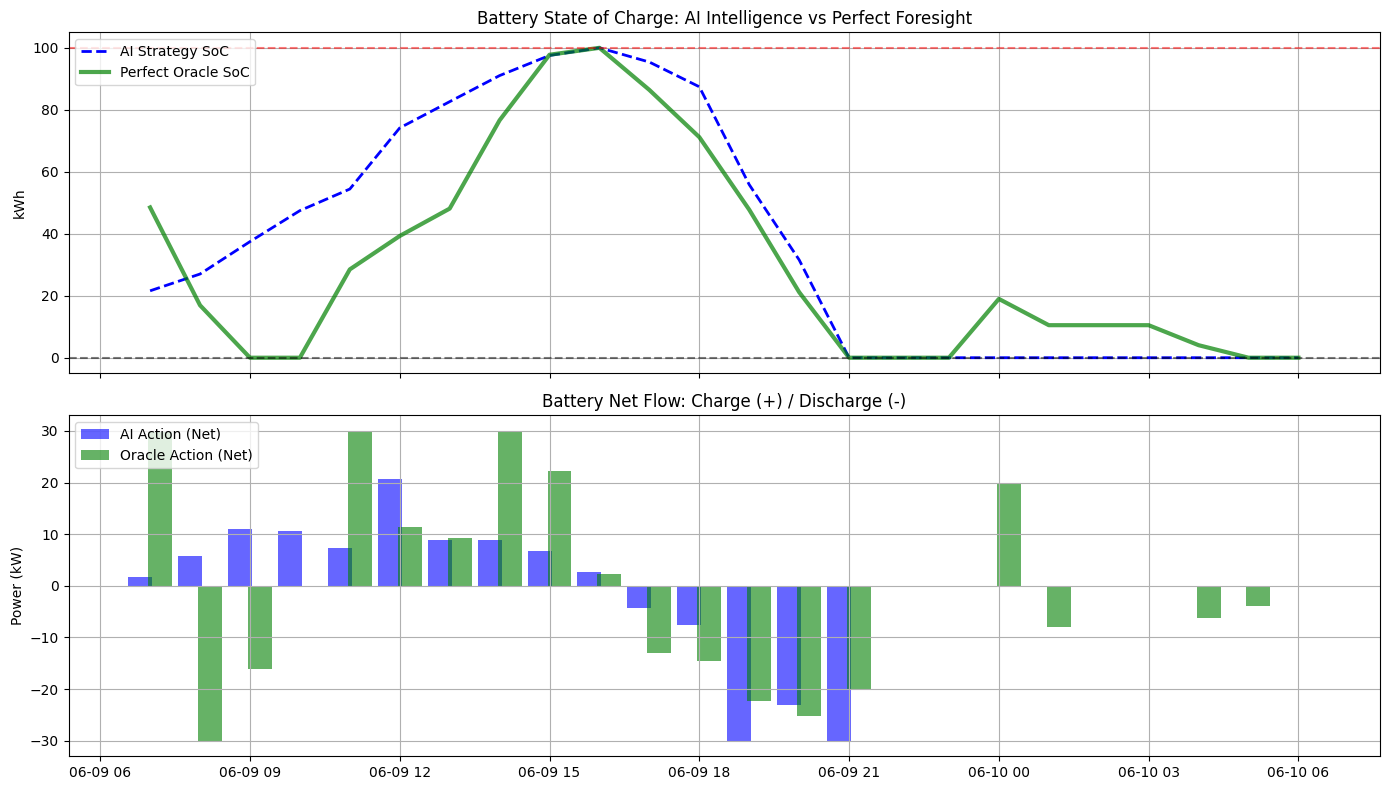

In [ ]:
# ==========================================
# 5. CALCULATE THE PERFECT FORESIGHT STRATEGY
# ==========================================
prob_real = pulp.LpProblem("Battery_Scheduling_Perfect", pulp.LpMinimize)

# New Decision Variables for the Oracle
P_buy_r = pulp.LpVariable.dicts("Buy_r_kW", times, lowBound=0)
P_sell_r = pulp.LpVariable.dicts("Sell_r_kW", times, lowBound=0)
P_charge_r = pulp.LpVariable.dicts("Charge_r_kW", times, lowBound=0, upBound=MAX_POWER)
P_discharge_r = pulp.LpVariable.dicts("Discharge_r_kW", times, lowBound=0, upBound=MAX_POWER)
SoC_r = pulp.LpVariable.dicts("SoC_r_kWh", times, lowBound=0, upBound=BATTERY_CAPACITY)

# Actual Data Arrays (Ground Truth)
pv_a = df_actuals["Solar_kW"].values
wind_a = df_actuals["Wind_kW"].values
demand_a = df_actuals["Demand_kW"].values
price_buy_a = df_actuals["Price_EUR_per_kWh"].values
price_sell_a = price_buy_a * 0.75  

# Objective: Minimize TRUE costs
prob_real += pulp.lpSum([P_buy_r[t] * price_buy_a[t] - P_sell_r[t] * price_sell_a[t] for t in times])

# Constraints
for t in times:
    # Energy Balance using REAL data
    prob_real += (pv_a[t] + wind_a[t] + P_buy_r[t] + P_discharge_r[t] == 
                  demand_a[t] + P_sell_r[t] + P_charge_r[t], f"EnergyBalance_r_{t}")
    
    # Battery State of Charge (SoC) Dynamics
    if t == 0:
        prob_real += (SoC_r[t] == INITIAL_SOC + (P_charge_r[t] * EFFICIENCY) - (P_discharge_r[t] / EFFICIENCY), f"SoC_r_{t}")
    else:
        prob_real += (SoC_r[t] == SoC_r[t-1] + (P_charge_r[t] * EFFICIENCY) - (P_discharge_r[t] / EFFICIENCY), f"SoC_r_{t}")

print("🔮 Running PuLP Optimizer on Perfect Foresight (Oracle)...")
status_real = prob_real.solve()

# ==========================================
# 6. EXTRACT & COMPARE
# ==========================================
# Extract the real optimal actions
df_opt["Oracle_Charge_kW"] = [P_charge_r[t].varValue for t in times]
df_opt["Oracle_Discharge_kW"] = [P_discharge_r[t].varValue for t in times]
df_opt["Oracle_SoC_kWh"] = [SoC_r[t].varValue for t in times]

# --- FINANCIAL COMPARISON ---
# What was the cost if we had perfect foresight?
oracle_cost = pulp.value(prob_real.objective)

# What was the cost of the AI's strategy if applied to reality?
# To calculate this, we take the physical battery actions the AI chose, 
# but calculate the resulting grid buy/sell using ACTUAL demand and solar.
ai_actual_cost = 0
for t in times:
    ai_charge = df_opt["Action_Charge_kW"].iloc[t]
    ai_discharge = df_opt["Action_Discharge_kW"].iloc[t]
    
    # What the grid MUST be to balance the AI's physical battery actions in reality
    net_load = demand_a[t] + ai_charge - pv_a[t] - wind_a[t] - ai_discharge
    
    if net_load > 0:
        ai_actual_cost += net_load * price_buy_a[t]
    else:
        ai_actual_cost += net_load * price_sell_a[t] # negative load means sell

print(f"\n💸 Financial Comparison over 24 Hours:")
print(f"Cost using Perfect Foresight (Oracle): € {oracle_cost:.2f}")
print(f"Cost using AI Forecast Strategy:       € {ai_actual_cost:.2f}")
print(f"Loss due to forecast errors:           € {ai_actual_cost - oracle_cost:.2f}")

# ==========================================
# 7. VISUALIZE AI vs ORACLE
# ==========================================
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: SoC Comparison
ax[0].plot(df_opt.index, df_opt["Optimal_SoC_kWh"], label="AI Strategy SoC", color="blue", linewidth=2, linestyle="--")
ax[0].plot(df_opt.index, df_opt["Oracle_SoC_kWh"], label="Perfect Oracle SoC", color="green", linewidth=3, alpha=0.7)
ax[0].axhline(BATTERY_CAPACITY, color="red", linestyle="--", alpha=0.5)
ax[0].axhline(0, color="black", linestyle="--", alpha=0.5)
ax[0].set_title("Battery State of Charge: AI Intelligence vs Perfect Foresight")
ax[0].set_ylabel("kWh")
ax[0].legend(loc="upper left")
ax[0].grid(True)

# Plot 2: Action Comparison
width = 0.02
ax[1].bar(df_opt.index - pd.Timedelta(hours=width*10), df_opt["Action_Charge_kW"] - df_opt["Action_Discharge_kW"], 
          label="AI Action (Net)", color="blue", width=width, alpha=0.6)
ax[1].bar(df_opt.index + pd.Timedelta(hours=width*10), df_opt["Oracle_Charge_kW"] - df_opt["Oracle_Discharge_kW"], 
          label="Oracle Action (Net)", color="green", width=width, alpha=0.6)
ax[1].set_title("Battery Net Flow: Charge (+) / Discharge (-)")
ax[1].set_ylabel("Power (kW)")
ax[1].legend(loc="upper left")
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Part 5: The Ultimate Comparison (Oracle vs AI vs Naive) 🏆
We introduce a naive baseline (last hour is our forecast).
We then run the optimizer on this dumb forecast to see how much money the AI is truly saving.

📉 Running PuLP Optimizer on Naive Forecast...

💰 24-HOUR FINANCIAL PERFORMANCE REPORT
1. Oracle (Perfect Foresight): € 11.23  <-- Theoretical Best
2. AI Forecast Strategy:       € 17.92
3. Naive Forecast Strategy:    € 28.49  <-- Dumb Baseline
--------------------------------------------------
🚀 AI Savings over Naive:      € 10.57 / day
💸 AI Loss vs Perfect Oracle:  € 6.69 / day



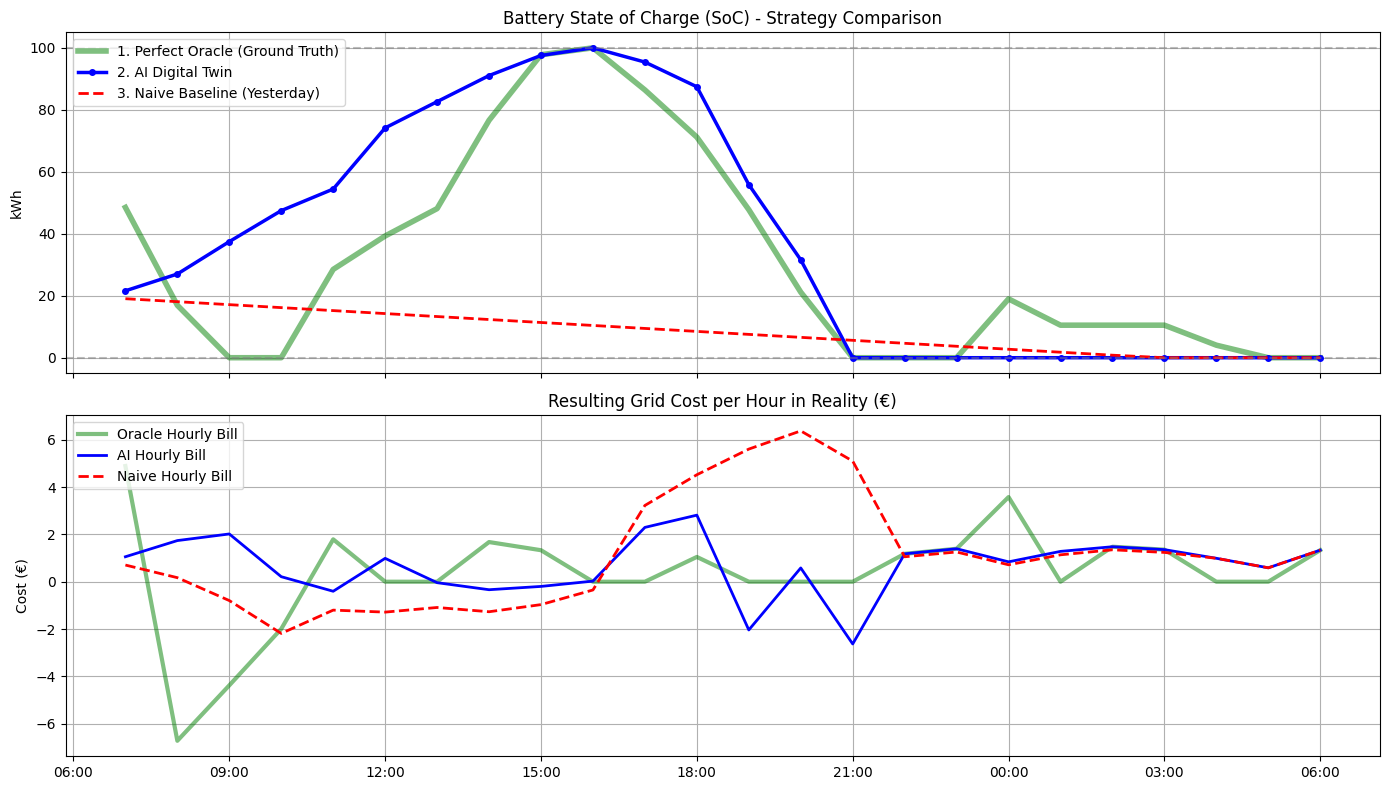

In [ ]:
# %%
# ==========================================
# 1. CREATE NAIVE FORECAST (Yesterday's Reality)
# ==========================================
# Grab the last hour
last_hour = df_test.iloc[START_IDX - 1]

# ==========================================
# 2. RUN OPTIMIZER FOR NAIVE BASELINE
# ==========================================
prob_naive = pulp.LpProblem("Battery_Scheduling_Naive", pulp.LpMinimize)

P_buy_n = pulp.LpVariable.dicts("Buy_n_kW", times, lowBound=0)
P_sell_n = pulp.LpVariable.dicts("Sell_n_kW", times, lowBound=0)
P_charge_n = pulp.LpVariable.dicts("Charge_n_kW", times, lowBound=0, upBound=MAX_POWER)
P_discharge_n = pulp.LpVariable.dicts("Discharge_n_kW", times, lowBound=0, upBound=MAX_POWER)
SoC_n = pulp.LpVariable.dicts("SoC_n_kWh", times, lowBound=0, upBound=BATTERY_CAPACITY)

# Naive Arrays (Yesterday's data)
pv_n = np.full(HORIZON, last_hour["Solar_kW"])
wind_n = np.full(HORIZON, last_hour["Wind_kW"])
demand_n = np.full(HORIZON, last_hour["Demand_kW"])
price_buy_n = np.full(HORIZON, last_hour["Price_EUR_per_kWh"])
price_sell_n = price_buy_n * 0.75  

prob_naive += pulp.lpSum([P_buy_n[t] * price_buy_n[t] - P_sell_n[t] * price_sell_n[t] for t in times])

for t in times:
    prob_naive += (pv_n[t] + wind_n[t] + P_buy_n[t] + P_discharge_n[t] == 
                   demand_n[t] + P_sell_n[t] + P_charge_n[t], f"EnergyBalance_n_{t}")
    if t == 0:
        prob_naive += (SoC_n[t] == INITIAL_SOC + (P_charge_n[t] * EFFICIENCY) - (P_discharge_n[t] / EFFICIENCY), f"SoC_n_{t}")
    else:
        prob_naive += (SoC_n[t] == SoC_n[t-1] + (P_charge_n[t] * EFFICIENCY) - (P_discharge_n[t] / EFFICIENCY), f"SoC_n_{t}")

print("📉 Running PuLP Optimizer on Naive Forecast...")
prob_naive.solve()

# ==========================================
# 3. FINANCIAL SIMULATOR (Applying strategies to reality)
# ==========================================
df_opt["Naive_Charge_kW"] = [P_charge_n[t].varValue for t in times]
df_opt["Naive_Discharge_kW"] = [P_discharge_n[t].varValue for t in times]
df_opt["Naive_SoC_kWh"] = [SoC_n[t].varValue for t in times]

def calculate_real_cost(charge_actions, discharge_actions):
    """Calculates the actual grid bill if these physical battery actions were executed in reality."""
    total_cost = 0
    for t in times:
        net_load = demand_a[t] + charge_actions.iloc[t] - pv_a[t] - wind_a[t] - discharge_actions.iloc[t]
        if net_load > 0:
            total_cost += net_load * price_buy_a[t]
        else:
            total_cost += net_load * price_sell_a[t]
    return total_cost

cost_oracle = calculate_real_cost(df_opt["Oracle_Charge_kW"], df_opt["Oracle_Discharge_kW"])
cost_ai     = calculate_real_cost(df_opt["Action_Charge_kW"], df_opt["Action_Discharge_kW"])
cost_naive  = calculate_real_cost(df_opt["Naive_Charge_kW"], df_opt["Naive_Discharge_kW"])

print("\n" + "="*50)
print(f"💰 24-HOUR FINANCIAL PERFORMANCE REPORT")
print("="*50)
print(f"1. Oracle (Perfect Foresight): € {cost_oracle:.2f}  <-- Theoretical Best")
print(f"2. AI Forecast Strategy:       € {cost_ai:.2f}")
print(f"3. Naive Forecast Strategy:    € {cost_naive:.2f}  <-- Dumb Baseline")
print("-" * 50)
print(f"🚀 AI Savings over Naive:      € {cost_naive - cost_ai:.2f} / day")
print(f"💸 AI Loss vs Perfect Oracle:  € {cost_ai - cost_oracle:.2f} / day")
print("="*50 + "\n")

# ==========================================
# 4. VISUALIZE THE STRATEGIES
# ==========================================
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: SoC Comparison
ax[0].plot(df_opt.index, df_opt["Oracle_SoC_kWh"], label="1. Perfect Oracle (Ground Truth)", color="green", linewidth=4, alpha=0.5)
ax[0].plot(df_opt.index, df_opt["Optimal_SoC_kWh"], label="2. AI Digital Twin", color="blue", linewidth=2.5, marker="o", markersize=4)
ax[0].plot(df_opt.index, df_opt["Naive_SoC_kWh"], label="3. Naive Baseline (Yesterday)", color="red", linewidth=2, linestyle="--")

ax[0].axhline(BATTERY_CAPACITY, color="grey", linestyle="--", alpha=0.5)
ax[0].axhline(0, color="grey", linestyle="--", alpha=0.5)
ax[0].set_title("Battery State of Charge (SoC) - Strategy Comparison")
ax[0].set_ylabel("kWh")
ax[0].legend(loc="upper left")
ax[0].grid(True)

# Plot 2: Grid Cost Profile
# Let's plot what the actual running cost per hour is for each strategy
cost_profile_oracle = (demand_a + df_opt["Oracle_Charge_kW"].values - pv_a - wind_a - df_opt["Oracle_Discharge_kW"].values) * price_buy_a
cost_profile_ai = (demand_a + df_opt["Action_Charge_kW"].values - pv_a - wind_a - df_opt["Action_Discharge_kW"].values) * price_buy_a
cost_profile_naive = (demand_a + df_opt["Naive_Charge_kW"].values - pv_a - wind_a - df_opt["Naive_Discharge_kW"].values) * price_buy_a

ax[1].plot(df_opt.index, cost_profile_oracle, label="Oracle Hourly Bill", color="green", linewidth=3, alpha=0.5)
ax[1].plot(df_opt.index, cost_profile_ai, label="AI Hourly Bill", color="blue", linewidth=2)
ax[1].plot(df_opt.index, cost_profile_naive, label="Naive Hourly Bill", color="red", linestyle="--", linewidth=2)

ax[1].set_title("Resulting Grid Cost per Hour in Reality (€)")
ax[1].set_ylabel("Cost (€)")
ax[1].legend(loc="upper left")
ax[1].grid(True)
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()